In [ ]:
# Proyecto: Descenso_Gradiente
# Sergio Raul Bonilla Alejo
# Dr. German Pineda
# Fecha: 26-Jun-2026

# **Notebook 6.2: Descenso por gradiente**

Este notebook implementa descenso por gradiente para ajustar un modelo lineal simple.

Ejecute las celdas en orden. Las celdas marcadas con `TODO` deben completarse por el estudiante.

**Objetivo:** calcular pérdida, gradiente y actualización de parámetros.


In [ ]:
# Importar librerías
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import ListedColormap

In [ ]:
# Crear datos de entrenamiento: 12 pares {x_i, y_i}
# Ajustar un modelo lineal a estos datos
data = np.array([[0.03,0.19,0.34,0.46,0.78,0.81,1.08,1.18,1.39,1.60,1.65,1.90],
                 [0.67,0.85,1.05,1.00,1.40,1.50,1.30,1.54,1.55,1.68,1.73,1.60]])

In [ ]:
# Definir el modelo: línea recta con intercepto phi[0] y pendiente phi[1]
def model(phi,x):
  y_pred = phi[0]+phi[1] * x
  return y_pred

In [ ]:
# Dibujar el modelo
def draw_model(data,model,phi,title=None):
  x_model = np.arange(0,2,0.01)
  y_model = model(phi,x_model)

  fix, ax = plt.subplots()
  ax.plot(data[0,:],data[1,:],'bo')
  ax.plot(x_model,y_model,'m-')
  ax.set_xlim([0,2]);ax.set_ylim([0,2])
  ax.set_xlabel('x'); ax.set_ylabel('y')
  ax.set_aspect('equal')
  if title is not None:
    ax.set_title(title)
  plt.show()

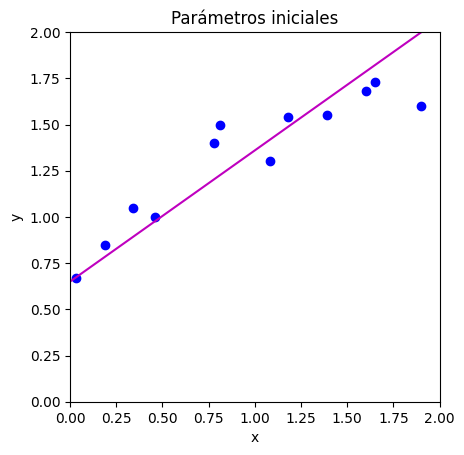

In [ ]:
# Inicializar parámetros arbitrarios y dibujar el modelo
phi = np.zeros((2,1))
phi[0] = 0.65      # Intercepto
phi[1] = 0.71      # Pendiente
draw_model(data,model,phi, "Parámetros iniciales")

## Pérdida de suma de cuadrados

Se implementa la pérdida:

$L(\phi)=\sum_i(f(x_i,\phi)-y_i)^2$


In [ ]:
def compute_loss(data_x, data_y, model, phi):
  # TODO -- Escribir esta función; reemplazar las líneas siguientes
  # Primero calcular predicciones del modelo usando data_x
  # Después calcular la diferencia cuadrada entre predicciones y valores reales
  # Finalmente sumar todos los términos y devolver la pérdida
  pred_y = 0
  loss = 0

  return loss

In [ ]:
import numpy as np

def compute_loss(data_x, data_y, model, phi):
    # Calcular predicciones del modelo usando data_x
    pred_y = model(phi, data_x)

    # Asegurar que pred_y y data_y tengan la misma forma para la resta
    pred_y = np.asarray(pred_y)
    data_y = np.asarray(data_y)

    # Si es necesario, aplanar vectores columna para operar elemento a elemento
    if pred_y.shape != data_y.shape:
        pred_y = pred_y.reshape(data_y.shape)

    # Calcular la diferencia cuadrada entre predicciones y valores reales
    squared_diff = (pred_y - data_y) ** 2

    # Sumar todos los términos y devolver la pérdida (suma de cuadrados)
    loss = np.sum(squared_diff)

    return loss


## Prueba rápida

Se verifica que la función de pérdida devuelva el valor esperado para parámetros conocidos.


In [ ]:
loss = compute_loss(data[0,:],data[1,:],model,np.array([[0.6],[-0.2]]))
print('Tu pérdida = %3.3f, pérdida esperada = %3.3f'%(loss, 12.367))

Tu pérdida = 12.367, pérdida esperada = 12.367


## Visualización de la superficie de pérdida

Se evalúa la pérdida en una malla de valores de los parámetros para observar la geometría del problema.


In [ ]:
def draw_loss_function(compute_loss, data,  model, phi_iters = None):
  # Definir un mapa de color para la gráfica
  my_colormap_vals_hex =('2a0902', '2b0a03', '2c0b04', '2d0c05', '2e0c06', '2f0d07', '300d08', '310e09', '320f0a', '330f0b', '34100b', '35110c', '36110d', '37120e', '38120f', '39130f', '3a1410', '3b1411', '3c1511', '3d1612', '3e1613', '3f1713', '401714', '411814', '421915', '431915', '451a16', '461b16', '471b17', '481c17', '491d18', '4a1d18', '4b1e19', '4c1f19', '4d1f1a', '4e201b', '50211b', '51211c', '52221c', '53231d', '54231d', '55241e', '56251e', '57261f', '58261f', '592720', '5b2821', '5c2821', '5d2922', '5e2a22', '5f2b23', '602b23', '612c24', '622d25', '632e25', '652e26', '662f26', '673027', '683027', '693128', '6a3229', '6b3329', '6c342a', '6d342a', '6f352b', '70362c', '71372c', '72372d', '73382e', '74392e', '753a2f', '763a2f', '773b30', '783c31', '7a3d31', '7b3e32', '7c3e33', '7d3f33', '7e4034', '7f4134', '804235', '814236', '824336', '834437', '854538', '864638', '874739', '88473a', '89483a', '8a493b', '8b4a3c', '8c4b3c', '8d4c3d', '8e4c3e', '8f4d3f', '904e3f', '924f40', '935041', '945141', '955242', '965343', '975343', '985444', '995545', '9a5646', '9b5746', '9c5847', '9d5948', '9e5a49', '9f5a49', 'a05b4a', 'a15c4b', 'a35d4b', 'a45e4c', 'a55f4d', 'a6604e', 'a7614e', 'a8624f', 'a96350', 'aa6451', 'ab6552', 'ac6552', 'ad6653', 'ae6754', 'af6855', 'b06955', 'b16a56', 'b26b57', 'b36c58', 'b46d59', 'b56e59', 'b66f5a', 'b7705b', 'b8715c', 'b9725d', 'ba735d', 'bb745e', 'bc755f', 'bd7660', 'be7761', 'bf7862', 'c07962', 'c17a63', 'c27b64', 'c27c65', 'c37d66', 'c47e67', 'c57f68', 'c68068', 'c78169', 'c8826a', 'c9836b', 'ca846c', 'cb856d', 'cc866e', 'cd876f', 'ce886f', 'ce8970', 'cf8a71', 'd08b72', 'd18c73', 'd28d74', 'd38e75', 'd48f76', 'd59077', 'd59178', 'd69279', 'd7937a', 'd8957b', 'd9967b', 'da977c', 'da987d', 'db997e', 'dc9a7f', 'dd9b80', 'de9c81', 'de9d82', 'df9e83', 'e09f84', 'e1a185', 'e2a286', 'e2a387', 'e3a488', 'e4a589', 'e5a68a', 'e5a78b', 'e6a88c', 'e7aa8d', 'e7ab8e', 'e8ac8f', 'e9ad90', 'eaae91', 'eaaf92', 'ebb093', 'ecb295', 'ecb396', 'edb497', 'eeb598', 'eeb699', 'efb79a', 'efb99b', 'f0ba9c', 'f1bb9d', 'f1bc9e', 'f2bd9f', 'f2bfa1', 'f3c0a2', 'f3c1a3', 'f4c2a4', 'f5c3a5', 'f5c5a6', 'f6c6a7', 'f6c7a8', 'f7c8aa', 'f7c9ab', 'f8cbac', 'f8ccad', 'f8cdae', 'f9ceb0', 'f9d0b1', 'fad1b2', 'fad2b3', 'fbd3b4', 'fbd5b6', 'fbd6b7', 'fcd7b8', 'fcd8b9', 'fcdaba', 'fddbbc', 'fddcbd', 'fddebe', 'fddfbf', 'fee0c1', 'fee1c2', 'fee3c3', 'fee4c5', 'ffe5c6', 'ffe7c7', 'ffe8c9', 'ffe9ca', 'ffebcb', 'ffeccd', 'ffedce', 'ffefcf', 'fff0d1', 'fff2d2', 'fff3d3', 'fff4d5', 'fff6d6', 'fff7d8', 'fff8d9', 'fffada', 'fffbdc', 'fffcdd', 'fffedf', 'ffffe0')
  my_colormap_vals_dec = np.array([int(element,base=16) for element in my_colormap_vals_hex])
  r = np.floor(my_colormap_vals_dec/(256*256))
  g = np.floor((my_colormap_vals_dec - r *256 *256)/256)
  b = np.floor(my_colormap_vals_dec - r * 256 *256 - g * 256)
  my_colormap = ListedColormap(np.vstack((r,g,b)).transpose()/255.0)

  # Crear una malla de valores de intercepto y pendiente
  intercepts_mesh, slopes_mesh = np.meshgrid(np.arange(0.0,2.0,0.02), np.arange(-1.0,1.0,0.002))
  loss_mesh = np.zeros_like(slopes_mesh)
  # Calcular la pérdida para cada conjunto de parámetros
  for idslope, slope in np.ndenumerate(slopes_mesh):
     loss_mesh[idslope] = compute_loss(data[0,:], data[1,:], model, np.array([[intercepts_mesh[idslope]], [slope]]))

  fig,ax = plt.subplots()
  fig.set_size_inches(8,8)
  ax.contourf(intercepts_mesh,slopes_mesh,loss_mesh,256,cmap=my_colormap)
  ax.contour(intercepts_mesh,slopes_mesh,loss_mesh,40,colors=['#80808080'])
  if phi_iters is not None:
    ax.plot(phi_iters[0,:], phi_iters[1,:],'go-')
  ax.set_ylim([1,-1])
  ax.set_xlabel('Intercept $\phi_{0}$'); ax.set_ylabel('Slope, $\phi_{1}$')
  plt.show()

<>:24: SyntaxWarning: invalid escape sequence '\p'
<>:24: SyntaxWarning: invalid escape sequence '\p'
<>:24: SyntaxWarning: invalid escape sequence '\p'
<>:24: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_16443/556461192.py:24: SyntaxWarning: invalid escape sequence '\p'
  ax.set_xlabel('Intercept $\phi_{0}$'); ax.set_ylabel('Slope, $\phi_{1}$')
/tmp/ipykernel_16443/556461192.py:24: SyntaxWarning: invalid escape sequence '\p'
  ax.set_xlabel('Intercept $\phi_{0}$'); ax.set_ylabel('Slope, $\phi_{1}$')


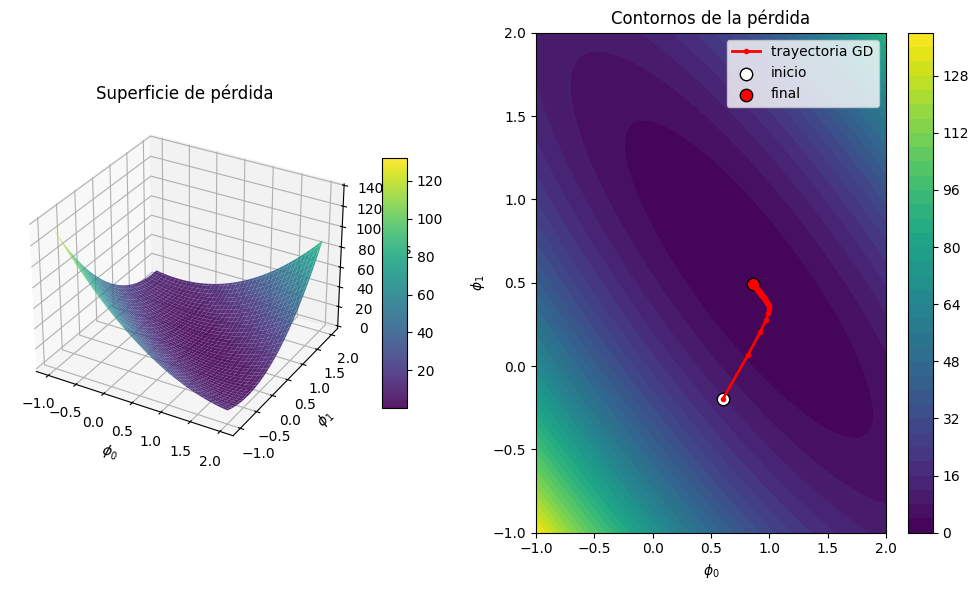

In [ ]:
# Código para visualizar la superficie de pérdida y la trayectoria del descenso
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D   # necesario para 3D
# plt.style.use('seaborn') # Comentado para evitar el error 'seaborn' no encontrado

# Parámetros de la malla
phi0_min, phi0_max = -1.0, 2.0   # ajustar según rango esperado
phi1_min, phi1_max = -1.0, 2.0
n_points = 80                    # resolución; bajar si es lento

phi0_vals = np.linspace(phi0_min, phi0_max, n_points)
phi1_vals = np.linspace(phi1_min, phi1_max, n_points)
P0, P1 = np.meshgrid(phi0_vals, phi1_vals)

# Evaluar la pérdida en cada punto de la malla
Z = np.zeros_like(P0)
for i in range(P0.shape[0]):
    for j in range(P0.shape[1]):
        phi_ij = np.array([[P0[i,j]], [P1[i,j]]])   # forma (2,1) como espera el notebook
        Z[i,j] = compute_loss(data[0,:], data[1,:], model, phi_ij)

# Dibujar superficie 3D
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot(121, projection='3d')
surf = ax.plot_surface(P0, P1, Z, cmap='viridis', edgecolor='none', alpha=0.9)
ax.set_xlabel(r'$\phi_0$')
ax.set_ylabel(r'$\phi_1$')
ax.set_zlabel('Loss')
ax.set_title('Superficie de pérdida')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)

# Dibujar contornos y superponer trayectoria del descenso
ax2 = fig.add_subplot(122)
cont = ax2.contourf(P0, P1, Z, levels=40, cmap='viridis')
ax2.set_xlabel(r'$\phi_0$')
ax2.set_ylabel(r'$\phi_1$')
ax2.set_title('Contornos de la pérdida')
fig.colorbar(cont, ax=ax2)

# Si tienes la historia de parámetros durante el descenso, superponerla
# Si no la tienes, aquí hay un ejemplo simple para generar una trayectoria con gradiente descendente fijo
try:
    history = history_phi  # si ya la guardaste en el notebook
except NameError:
    # Generar una trayectoria de ejemplo con compute_gradient y learning rate fijo
    history = []
    phi = np.array([[0.6], [-0.2]])   # punto inicial; ajustar si quieres
    lr = 0.01
    for k in range(50):
        history.append(phi.copy())
        grad = compute_gradient(data[0,:], data[1,:], phi)   # devuelve (2,1)
        phi = phi - lr * grad

history = np.concatenate(history, axis=1)  # shape (2, n_steps)

# Superponer en la gráfica de contornos
ax2.plot(history[0,:], history[1,:], 'r.-', linewidth=2, markersize=6, label='trayectoria GD')
ax2.scatter(history[0,0], history[1,0], color='white', edgecolor='k', s=80, label='inicio')
ax2.scatter(history[0,-1], history[1,-1], color='red', edgecolor='k', s=80, label='final')
ax2.legend()

plt.tight_layout()
plt.show()

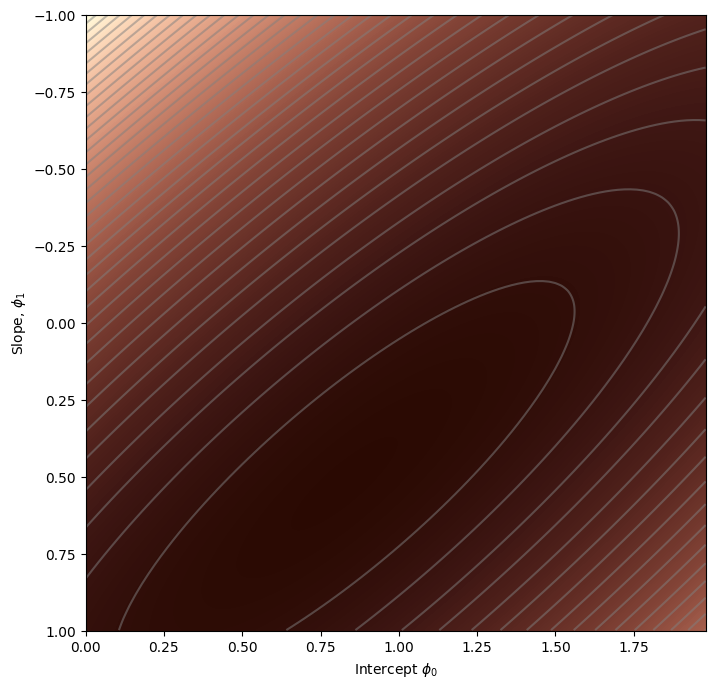

In [ ]:
draw_loss_function(compute_loss, data, model)

## Gradiente esperado

Se implementa el vector de derivadas parciales respecto a los parámetros:

$$

abla_\phi L =
\begin{bmatrix}
\frac{\partial L}{\partial \phi_0} \\
\frac{\partial L}{\partial \phi_1}
\end{bmatrix}
$$


In [ ]:
# Este gradiente puede derivarse a partir de la pérdida de suma de cuadrados.
# Se recomienda escribir la pérdida y derivarla respecto a phi0 y phi1.
# Derivar respecto a phi0 y phi1.
def compute_gradient(data_x, data_y, phi):
    # TODO -- Escribir esta función; reemplazar las líneas siguientes
    dl_dphi0 = 0.0
    dl_dphi1 = 0.0

    # Devolver el gradiente
    return np.array([[dl_dphi0],[dl_dphi1]])

In [ ]:
import numpy as np

def gradient_descent_step(phi, data, model):

    #Realiza un paso de descenso por gradiente con búsqueda lineal.
    #phi   : array shape (2,1) o (2,) con los parámetros actuales
    #data  : matriz data usada en el notebook (data[0,:]=x, data[1,:]=y)
    #model : función model(phi, x) definida en el notebook

    #Devuelve: phi actualizado con la misma forma que la entrada

    # Asegurar formas consistentes
    phi_arr = np.asarray(phi).reshape(2,1)   # trabajar internamente como (2,1)

    # 1) Calcular el gradiente usando la función implementada en el notebook
    grad = compute_gradient(data[0,:], data[1,:], phi_arr)   # devuelve (2,1)

    # 2) Encontrar el tamaño de paso alpha usando la búsqueda lineal definida en el notebook
    #    La función line_search tiene la firma: line_search(data, model, phi, gradient, ...)
    alpha = line_search(data, model, phi_arr, grad)

    # 3) Actualizar los parámetros: phi <- phi - alpha * grad
    phi_new = phi_arr - alpha * grad

    # Devolver con la misma forma que la entrada original
    if np.asarray(phi).ndim == 1 or np.asarray(phi).shape == (2,):
        return phi_new.reshape(2,)
    else:
        return phi_new


In [ ]:
import numpy as np

def compute_gradient(data_X, data_y, phi):

    #data_X : array-like shape (n,) o (n,1) con los valores x_i
    #data_y : array-like shape (n,) o (n,1) con los valores y_i
    #phi    : array-like shape (2,1) o (2,) con [phi0, phi1]
    #Devuelve: np.array([[dL_dphi0],[dL_dphi1]])

    x = np.asarray(data_X).reshape(-1)
    y = np.asarray(data_y).reshape(-1)
    phi = np.asarray(phi).reshape(2)

    phi0, phi1 = phi[0], phi[1]

    # Predicciones del modelo lineal
    pred = phi0 + phi1 * x

    # Residuales
    r = pred - y

    # Gradientes (suma de cuadrados, no promedio)
    dL_dphi0 = 2.0 * np.sum(r)
    dL_dphi1 = 2.0 * np.sum(r * x)

    return np.array([[dL_dphi0], [dL_dphi1]])


## Verificación con diferencias finitas

Las diferencias finitas aproximan el gradiente cambiando un parámetro por una cantidad pequeña \(\delta\):

$$
\frac{\partial L}{\partial \phi_0}\approx
\frac{L(\phi_0+\delta,\phi_1)-L(\phi_0,\phi_1)}{\delta}
$$

$$
\frac{\partial L}{\partial \phi_1}\approx
\frac{L(\phi_0,\phi_1+\delta)-L(\phi_0,\phi_1)}{\delta}
$$

Este método es útil para verificar gradientes, pero no escala bien cuando hay muchos parámetros.


In [ ]:
# Calcular el gradiente usando la función implementada
gradient = compute_gradient(data[0,:],data[1,:], phi)
print("Tus gradientes: (%3.3f,%3.3f)"%(gradient[0],gradient[1]))
# Aproximar el gradiente con diferencias finitas
delta = 0.0001
dl_dphi0_est = (compute_loss(data[0,:],data[1,:],model,phi+np.array([[delta],[0]])) - \
                    compute_loss(data[0,:],data[1,:],model,phi))/delta
dl_dphi1_est = (compute_loss(data[0,:],data[1,:],model,phi+np.array([[0],[delta]])) - \
                    compute_loss(data[0,:],data[1,:],model,phi))/delta
print("Gradientes aproximados: (%3.3f,%3.3f)"%(dl_dphi0_est,dl_dphi1_est))
# Puede haber pequeñas diferencias porque las diferencias finitas son una aproximación

Tus gradientes: (0.120,-0.105)
Gradientes aproximados: (0.121,-0.104)


/tmp/ipykernel_16443/3049326853.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("Tus gradientes: (%3.3f,%3.3f)"%(gradient[0],gradient[1]))


## Descenso por gradiente con búsqueda lineal

Se usa una rutina de búsqueda lineal para elegir el tamaño de paso \(\alpha\) en la dirección de descenso.

$$
\phi_{t+1}=\phi_t-\alpha
abla_\phi L(\phi_t)
$$


In [ ]:
def loss_function_1D(dist_prop, data, model, phi_start, search_direction):
  # Devolver la pérdida después de avanzar esta distancia
  return compute_loss(data[0,:], data[1,:], model, phi_start - search_direction * dist_prop)

def line_search(data, model, phi, gradient, thresh=.00001, max_dist = 0.1, max_iter = 15, verbose=False):
    # Inicializar cuatro puntos dentro del intervalo de búsqueda
    a = 0
    b = 0.33 * max_dist
    c = 0.66 * max_dist
    d = 1.0 * max_dist
    n_iter = 0

    # Iterar hasta aproximar suficientemente el mínimo
    while np.abs(b-c) > thresh and n_iter < max_iter:
        # Incrementar el contador de iteraciones para evitar bucles infinitos
        n_iter = n_iter+1
        # Calcular la pérdida en los cuatro puntos
        lossa = loss_function_1D(a, data, model, phi, gradient)
        lossb = loss_function_1D(b, data, model, phi, gradient)
        lossc = loss_function_1D(c, data, model, phi, gradient)
        lossd = loss_function_1D(d, data, model, phi, gradient)

        if verbose:
          print('Iter %d, a=%3.3f, b=%3.3f, c=%3.3f, d=%3.3f'%(n_iter, a,b,c,d))
          print('a %f, b%f, c%f, d%f'%(lossa,lossb,lossc,lossd))

        # Regla 1: si la pérdida en A es menor que en B, C y D, acercar B, C y D hacia A
        if np.argmin((lossa,lossb,lossc,lossd))==0:
          b = a+ (b-a)/2
          c = a+ (c-a)/2
          d = a+ (d-a)/2
          continue;

        # Regla 2: si la pérdida en b es menor que en c,
        #                     el punto d toma el valor de c,
        #                     b queda a 1/3 entre a y el nuevo d
        #                     c queda a 2/3 entre a y el nuevo d
        if lossb < lossc:
          d = c
          b = a+ (d-a)/3
          c = a+ 2*(d-a)/3
          continue

        # Regla 3: si la pérdida en c es menor que en b,
        #                     el punto a toma el valor de b,
        #                     b queda a 1/3 entre el nuevo a y d
        #                     c queda a 2/3 entre el nuevo a y d
        a = b
        b = a+ (d-a)/3
        c = a+ 2*(d-a)/3

    # Devolver el promedio de los dos puntos centrales
    return (b+c)/2.0

In [ ]:
def gradient_descent_step(phi, data,  model):
  # TODO -- Actualizar phi con el paso de descenso por gradiente: phi <- phi - alpha * grad
  # 1. Calcular el gradiente usando la función anterior
  # 2. Encontrar el tamaño de paso alpha usando búsqueda lineal
  # 3. Actualizar los parámetros phi con el gradiente y alpha

  return phi

In [ ]:
import numpy as np

def compute_loss(data_x, data_y, model, phi):

    #L(phi) = sum_i ( f(x_i,phi) - y_i )^2
    #data_x : array-like (n,) o (n,1)
    #data_y : array-like (n,) o (n,1)
    #model  : función model(phi, x) que devuelve predicciones compatibles con data_y
    #phi    : parámetros (por ejemplo shape (2,1) o (2,))
   # Devuelve: escalar (suma de cuadrados)

    # Obtener predicciones usando la función model (asumida en el notebook)
    pred_y = np.asarray(model(phi, data_x))
    y = np.asarray(data_y)

    # Aplanar a vectores 1D para operar elemento a elemento
    pred_y = pred_y.reshape(-1)
    y = y.reshape(-1)

    # Comprobar que tengan la misma longitud
    if pred_y.shape[0] != y.shape[0]:
        raise ValueError("predicciones y data_y deben tener la misma cantidad de elementos")

    # Suma de cuadrados
    squared_diff = (pred_y - y) ** 2
    loss = np.sum(squared_diff)

    return loss


def compute_gradient(data_X, data_y, phi):

    #Gradiente de L respecto a phi para modelo lineal f(x)=phi0 + phi1*x
    #data_X : array-like (n,) o (n,1)
    #data_y : array-like (n,) o (n,1)
    #phi    : array-like (2,1) o (2,) con [phi0, phi1]
    #Devuelve: np.array([[dL_dphi0],[dL_dphi1]]) (vector columna)

    x = np.asarray(data_X).reshape(-1)
    y = np.asarray(data_y).reshape(-1)
    phi = np.asarray(phi).reshape(2)

    phi0, phi1 = phi[0], phi[1]

    # Predicciones del modelo lineal
    pred = phi0 + phi1 * x

    # Residuales
    r = pred - y

    # Gradientes (para L = sum (r_i)^2)
    dL_dphi0 = 2.0 * np.sum(r)
    dL_dphi1 = 2.0 * np.sum(r * x)

    return np.array([[dL_dphi0], [dL_dphi1]])


In [ ]:
phi0 = np.array([[0.6],[-0.2]])
phi_next = gradient_descent_step(phi0, data, model)
print("phi siguiente:\n", phi_next)


phi siguiente:
 [[ 0.6]
 [-0.2]]


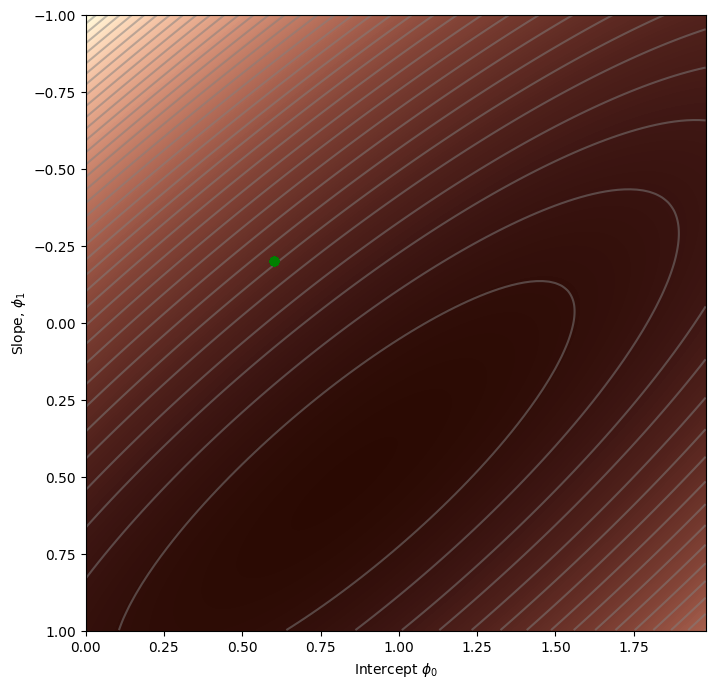

In [ ]:
phi = np.array([[0.6],[-0.2]])
history = [phi.copy()]
for k in range(10):
    phi = gradient_descent_step(phi, data, model)
    history.append(phi.copy())
history = np.concatenate(history, axis=1)   # shape (2, n_steps+1)
draw_loss_function(compute_loss, data, model, history)  # traza la trayectoria sobre los contornos


In [ ]:
# Asumiendo que en el notebook existe:
# - data: matriz donde data[0,:] son x y data[1,:] son y
# - model(phi, x) definido como phi0 + phi1 * x

phi_test = np.array([[0.6], [-0.2]])
loss = compute_loss(data[0,:], data[1,:], model, phi_test)
print("Tu pérdida = %3.3f, pérdida esperada = %3.3f" % (loss, 12.367))

grad = compute_gradient(data[0,:], data[1,:], phi_test)
print("Gradiente:\n", grad)


Tu pérdida = 12.367, pérdida esperada = 12.367
Gradiente:
 [[-21.904  ]
 [-26.84044]]


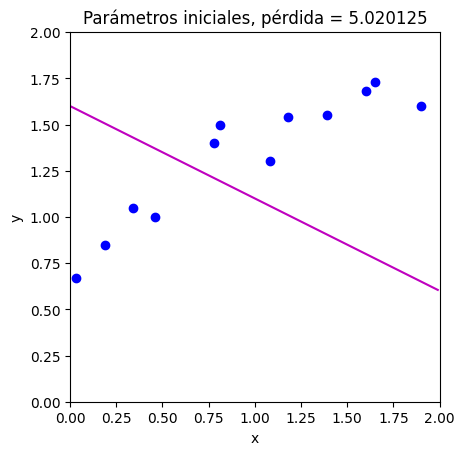

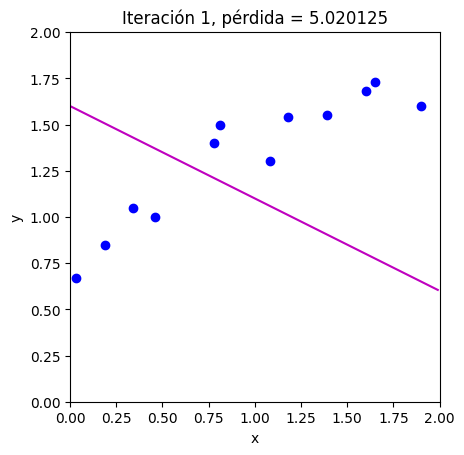

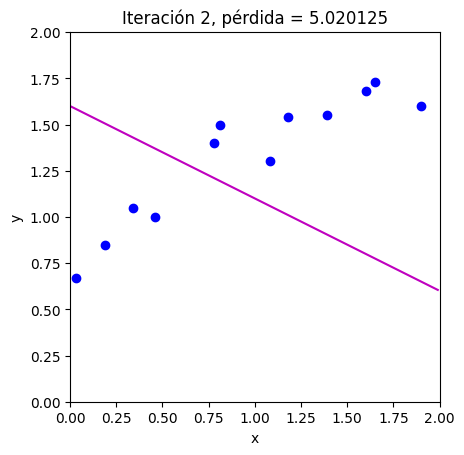

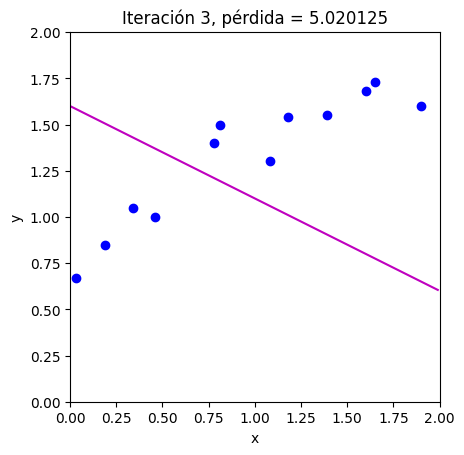

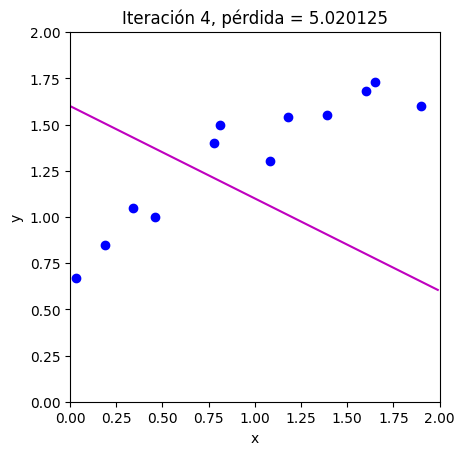

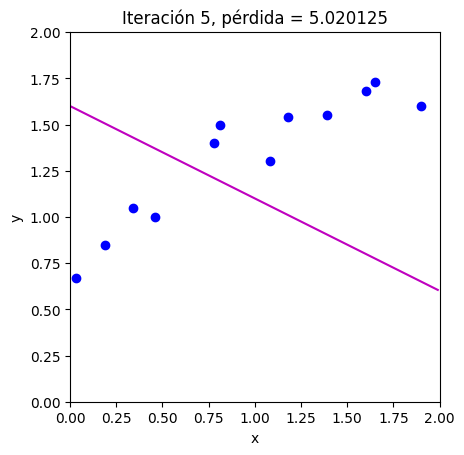

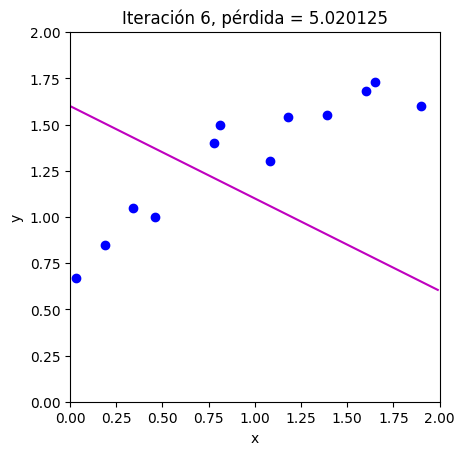

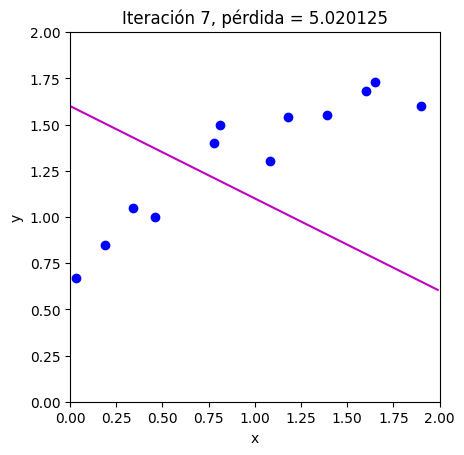

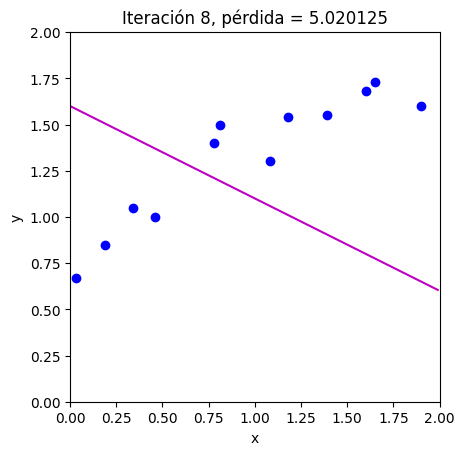

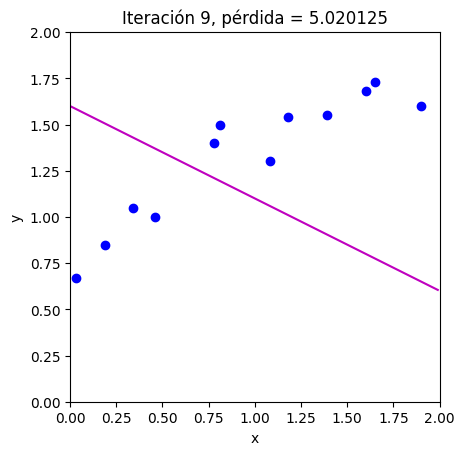

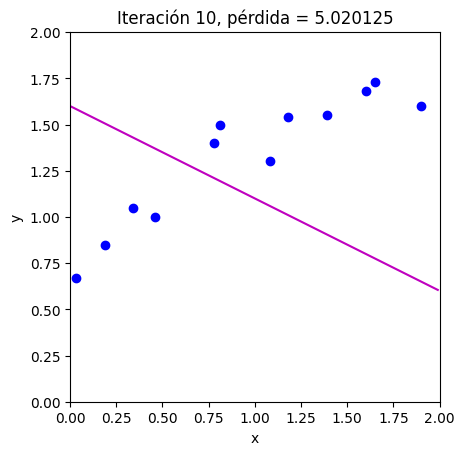

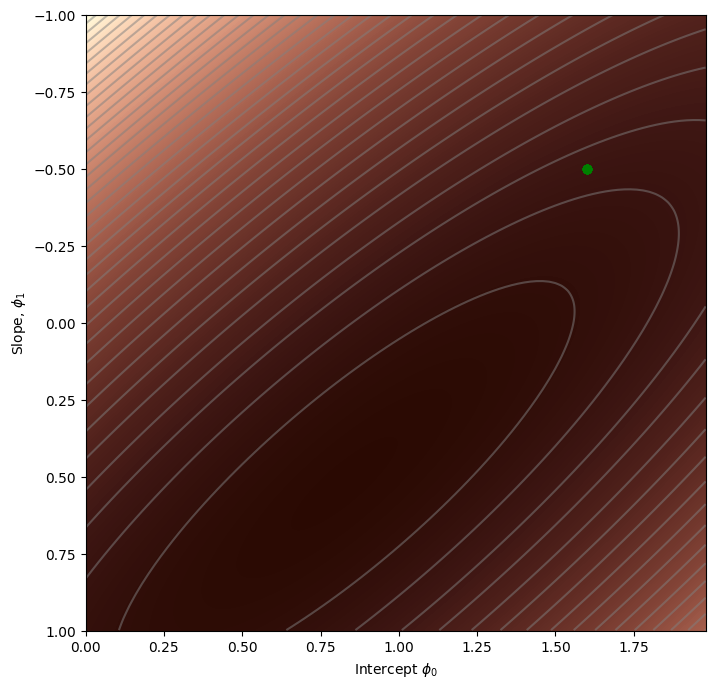

In [ ]:
# Inicializar parámetros y dibujar el modelo
n_steps = 10
phi_all = np.zeros((2,n_steps+1))
phi_all[0,0] = 1.6
phi_all[1,0] = -0.5

# Medir la pérdida y dibujar el modelo inicial
loss =  compute_loss(data[0,:], data[1,:], model, phi_all[:,0:1])
draw_model(data,model,phi_all[:,0:1], "Parámetros iniciales, pérdida = %f"%(loss))

# Repetir pasos de descenso por gradiente
for c_step in range (n_steps):
  # Ejecutar un paso de descenso por gradiente
  phi_all[:,c_step+1:c_step+2] = gradient_descent_step(phi_all[:,c_step:c_step+1],data, model)
  # Medir la pérdida y dibujar el modelo
  loss =  compute_loss(data[0,:], data[1,:], model, phi_all[:,c_step+1:c_step+2])
  draw_model(data,model,phi_all[:,c_step+1], "Iteración %d, pérdida = %f"%(c_step+1,loss))

# Dibujar la trayectoria sobre la superficie de pérdida
draw_loss_function(compute_loss, data, model,phi_all)